#### 1-Load data and Visualization

In [ ]:
import numpy as np
import struct

def read_images(filename):
    with open(filename, 'rb') as f:
        _, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
        data = data.reshape(num_images, rows, cols)
    return data

def read_labels(filename):
    with open(filename, 'rb') as f:
        _, num_items = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

train_images = read_images("./Dataset/train-images-idx3-ubyte")
train_labels = read_labels("./Dataset/train-labels-idx1-ubyte")
test_images  = read_images("./Dataset/t10k-images-idx3-ubyte")
test_labels  = read_labels("./Dataset/t10k-labels-idx1-ubyte")

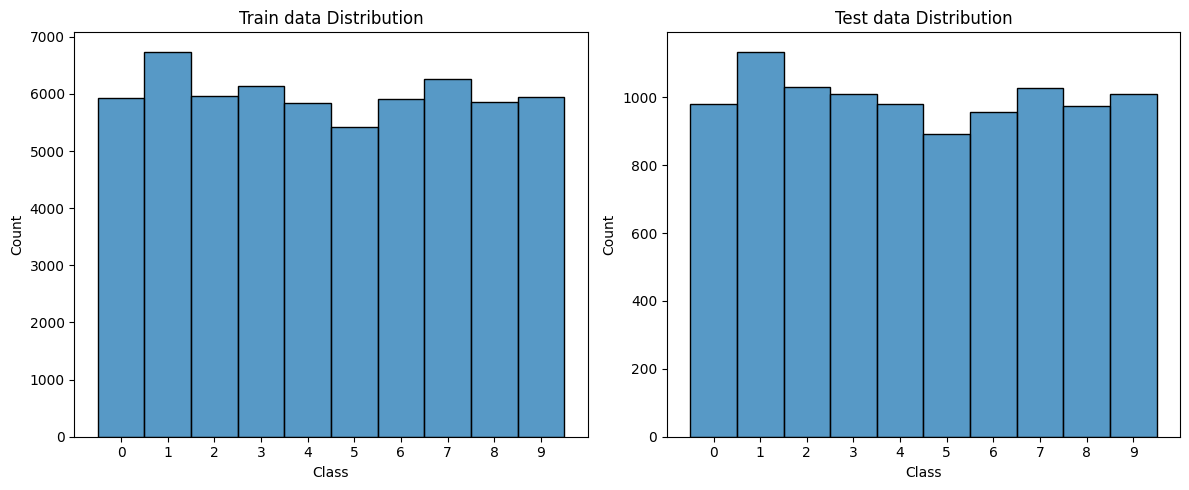

Shape of original train images: (60000, 28, 28)
Shape of processed train images: (60000, 784)
Shape of original test images: (10000, 28, 28)
Shape of processed test images: (10000, 784)


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(train_labels, kde=False, bins=np.arange(0, 11) - 0.5)
plt.title('Train data Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(range(10))

plt.subplot(1, 2, 2)
sns.histplot(test_labels, kde=False, bins=np.arange(0, 11) - 0.5)
plt.title('Test data Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(range(10))

plt.tight_layout()
plt.show()

def preprocess_data(images, labels):
    images = images.reshape(images.shape[0], -1) / 255.0
    return images, labels

train_images_processed, train_labels_processed = preprocess_data(train_images, train_labels)
test_images_processed, test_labels_processed = preprocess_data(test_images, test_labels)

print("Shape of original train images:", train_images.shape)
print("Shape of processed train images:", train_images_processed.shape)
print("Shape of original test images:", test_images.shape)
print("Shape of processed test images:", test_images_processed.shape)


#### 2-Implement AutoEncoders

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Convert numpy arrays to torch tensors
train_images_tensor = torch.tensor(train_images_processed, dtype=torch.float32).to(device)
train_labels_tensor = torch.tensor(train_labels_processed, dtype=torch.long).to(device)
test_images_tensor = torch.tensor(test_images_processed, dtype=torch.float32).to(device)
test_labels_tensor = torch.tensor(test_labels_processed, dtype=torch.long).to(device)

batch_size = 256

train_dataset = TensorDataset(train_images_tensor, train_images_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(test_images_tensor, test_images_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: mps


In [ ]:

# Model 1: 8 neuron output encoder
class Autoencoder1(nn.Module):
    def __init__(self):
        super(Autoencoder1, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(True),
            nn.Linear(128, 8),
            nn.ReLU(True)
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 128),
            nn.ReLU(True),
            nn.Linear(128, 784),
            nn.ReLU(True)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Model 2: 4 neuron output encoder
class Autoencoder2(nn.Module):
    def __init__(self):
        super(Autoencoder2, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(True),
            nn.Linear(128, 4),
            nn.ReLU(True)
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 128),
            nn.ReLU(True),
            nn.Linear(128, 784),
            nn.ReLU(True) 
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


# Training function
def train_model(model, train_loader, criterion, optimizer, epochs, model_name):
    print(f"Training {model_name}...")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_idx, (data, _) in enumerate(train_loader): # Unpack data, ignore target as it's the same
            data = data.to(device)
            # Forward pass
            outputs = model(data)
            loss = criterion(outputs, data) # Reconstruct the input data

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}')
    print(f"{model_name} training finished.")


def evaluate_model(model, test_loader, criterion, model_name):
    print(f"Evaluating {model_name}...")
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            outputs = model(data)
            loss = criterion(outputs, data)
            total_loss += loss.item() * data.size(0)
    avg_loss = total_loss / len(test_loader.dataset)
    print(f'{model_name} Test Reconstruction Loss: {avg_loss:.6f}')
    return avg_loss

#### 3-Train AutoEncoders

In [ ]:
# Training parameters
num_epochs = 50
criterion = nn.MSELoss()

model1 = Autoencoder1().to(device)
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)
train_model(model1, train_loader, criterion, optimizer1, num_epochs, "Autoencoder 1 (8 neurons)")
test_loss1 = evaluate_model(model1, test_loader, criterion, "Autoencoder 1 (8 neurons)")


model2 = Autoencoder2().to(device)
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)
train_model(model2, train_loader, criterion, optimizer2, num_epochs, "Autoencoder 2 (4 neurons)")
test_loss2 = evaluate_model(model2, test_loader, criterion, "Autoencoder 2 (4 neurons)")

Training Autoencoder 1 (8 neurons)...
Epoch [10/50], Loss: 0.030086
Epoch [20/50], Loss: 0.028597
Epoch [30/50], Loss: 0.027651
Epoch [40/50], Loss: 0.026833
Epoch [50/50], Loss: 0.026565
Autoencoder 1 (8 neurons) training finished.
Training Autoencoder 2 (4 neurons)...
Epoch [10/50], Loss: 0.045883
Epoch [20/50], Loss: 0.043361
Epoch [30/50], Loss: 0.042671
Epoch [40/50], Loss: 0.042026
Epoch [50/50], Loss: 0.041664
Autoencoder 2 (4 neurons) training finished.
Evaluating Autoencoder 1 (8 neurons)...
Autoencoder 1 (8 neurons) Test Reconstruction Loss: 0.026858
Evaluating Autoencoder 2 (4 neurons)...
Autoencoder 2 (4 neurons) Test Reconstruction Loss: 0.042628


#### 4- Classifier

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Ensure models are on the correct device and move to evaluation mode
model1.to(device).eval()
model2.to(device).eval()

# Freeze encoder parameters for both models
for param in model1.encoder.parameters():
    param.requires_grad = False

for param in model2.encoder.parameters():
    param.requires_grad = False

class Classifier1(nn.Module):
    def __init__(self):
        super(Classifier1, self).__init__()
        self.encoder = model1.encoder
        self.classifier = nn.Sequential(
            nn.Linear(8, 4),
            nn.ReLU(True),
            nn.Linear(4, 10)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        output = self.classifier(encoded)
        return output

class Classifier2(nn.Module):
    def __init__(self):
        super(Classifier2, self).__init__()
        self.encoder = model2.encoder
        self.classifier = nn.Sequential(
            nn.Linear(4, 10)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        output = self.classifier(encoded)
        return output

def train_classifier(model, train_loader, criterion, optimizer, epochs, model_name):
    train_losses_history = []
    train_accuracies_history = []

    print(f"Training {model_name}...")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for i, (data, labels) in enumerate(train_loader):
            data, labels = data.to(device), labels.to(device)

            # Forward pass
            outputs = model(data)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

        avg_loss = running_loss / len(train_loader)
        accuracy = 100 * correct_predictions / total_samples

        train_losses_history.append(avg_loss)
        train_accuracies_history.append(accuracy)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_loss:.6f}, Train Accuracy: {accuracy:.2f}%')
    print(f"{model_name} training finished.")
    return train_losses_history, train_accuracies_history

def evaluate_classifier(model, test_loader, criterion, model_name):
    print(f"Evaluating {model_name}...")
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    with torch.no_grad():
        for data, labels in test_loader:
            data, labels = data.to(device), labels.to(device)
            outputs = model(data)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * data.size(0) # Multiply by batch size for accurate avg loss
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    avg_loss = running_loss / total_samples
    accuracy = 100 * correct_predictions / total_samples
    print(f'{model_name} Test Loss: {avg_loss:.6f}, Test Accuracy: {accuracy:.2f}%')
    return avg_loss, accuracy


batch_size_clf = 256
# Ensure labels are also on the correct device
train_labels_tensor = train_labels_tensor.to(device)
test_labels_tensor = test_labels_tensor.to(device)

train_dataset_clf = TensorDataset(train_images_tensor, train_labels_tensor)
train_loader_clf = DataLoader(train_dataset_clf, batch_size=batch_size_clf, shuffle=True)

test_dataset_clf = TensorDataset(test_images_tensor, test_labels_tensor)
test_loader_clf = DataLoader(test_dataset_clf, batch_size=batch_size_clf, shuffle=False)


In [37]:
num_epochs_clf = 30
criterion_clf = nn.CrossEntropyLoss()

classifier1 = Classifier1().to(device)
optimizer_clf1 = optim.Adam(classifier1.parameters(), lr=0.001)
train_loss_hist1, train_acc_hist1 = train_classifier(classifier1, train_loader_clf, criterion_clf, optimizer_clf1, num_epochs_clf, "Classifier 1")
test_loss1, test_acc1 = evaluate_classifier(classifier1, test_loader_clf, criterion_clf, "Classifier 1")


classifier2 = Classifier2().to(device)
optimizer_clf2 = optim.Adam(classifier2.parameters(), lr=0.001)
train_loss_hist2, train_acc_hist2 = train_classifier(classifier2, train_loader_clf, criterion_clf, optimizer_clf2, num_epochs_clf, "Classifier 2")
test_loss2, test_acc2 = evaluate_classifier(classifier2, test_loader_clf, criterion_clf, "Classifier 2")


Training Classifier 1...
Epoch [5/30], Train Loss: 1.007871, Train Accuracy: 67.68%
Epoch [10/30], Train Loss: 0.760927, Train Accuracy: 78.22%
Epoch [15/30], Train Loss: 0.690549, Train Accuracy: 79.89%
Epoch [20/30], Train Loss: 0.657410, Train Accuracy: 80.47%
Epoch [25/30], Train Loss: 0.637571, Train Accuracy: 80.77%
Epoch [30/30], Train Loss: 0.625342, Train Accuracy: 81.04%
Classifier 1 training finished.
Evaluating Classifier 1...
Classifier 1 Test Loss: 0.634607, Test Accuracy: 81.11%
Training Classifier 2...
Epoch [5/30], Train Loss: 1.423616, Train Accuracy: 53.55%
Epoch [10/30], Train Loss: 1.154229, Train Accuracy: 66.18%
Epoch [15/30], Train Loss: 1.033997, Train Accuracy: 68.52%
Epoch [20/30], Train Loss: 0.964170, Train Accuracy: 69.87%
Epoch [25/30], Train Loss: 0.921332, Train Accuracy: 70.46%
Epoch [30/30], Train Loss: 0.895045, Train Accuracy: 70.70%
Classifier 2 training finished.
Evaluating Classifier 2...
Classifier 2 Test Loss: 0.880350, Test Accuracy: 70.65%


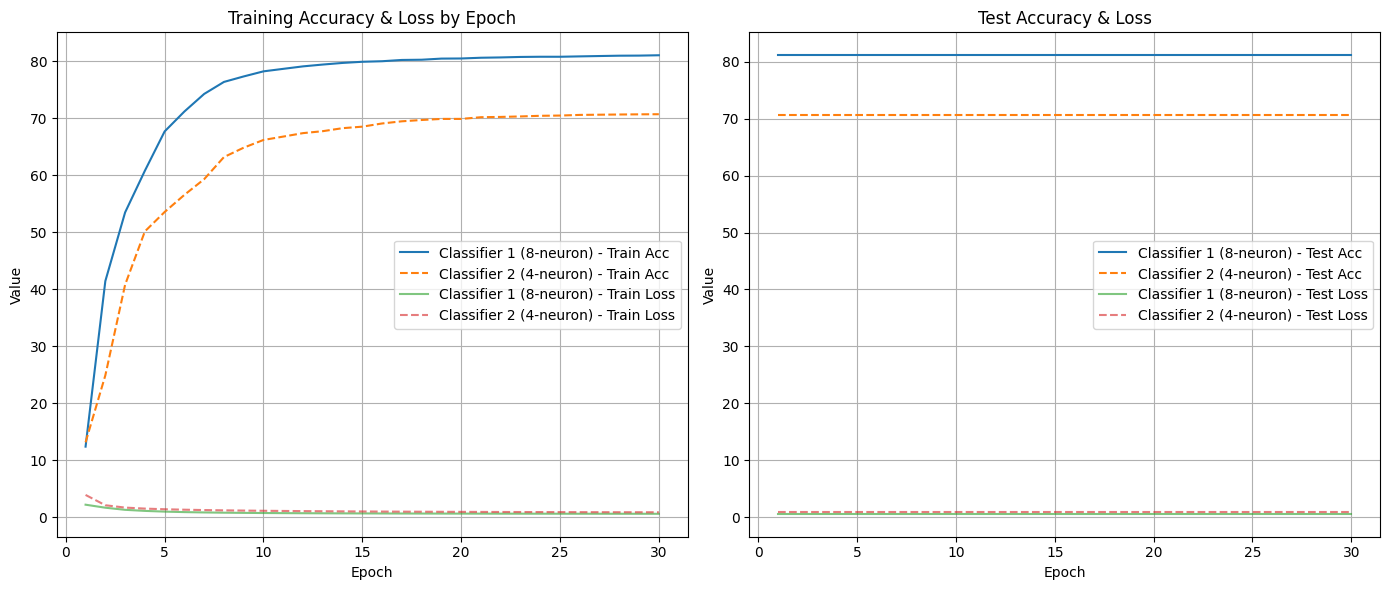


--- Parameter Count (Trainable Parameters) ---
Classifier 1 (based on 8-neuron encoder): 86 parameters
Classifier 2 (based on 4-neuron encoder): 50 parameters

--- Performance Summary ---
Classifier 1 (8-neuron encoder):
  - Best Training Accuracy: 81.04%
  - Final Test Accuracy: 81.11%

Classifier 2 (4-neuron encoder):
  - Best Training Accuracy: 70.70%
  - Final Test Accuracy: 70.65%


In [40]:
epochs_range = range(1, num_epochs_clf + 1)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc_hist1, label='Classifier 1 (8-neuron) - Train Acc')
plt.plot(epochs_range, train_acc_hist2, label='Classifier 2 (4-neuron) - Train Acc', linestyle='--')
plt.plot(epochs_range, train_loss_hist1, label='Classifier 1 (8-neuron) - Train Loss', alpha=0.6)
plt.plot(epochs_range, train_loss_hist2, label='Classifier 2 (4-neuron) - Train Loss', linestyle='--', alpha=0.6)
plt.title('Training Accuracy & Loss by Epoch')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, [test_acc1]*num_epochs_clf, label='Classifier 1 (8-neuron) - Test Acc') # Plotting the final test accuracy for all epochs for comparison
plt.plot(epochs_range, [test_acc2]*num_epochs_clf, label='Classifier 2 (4-neuron) - Test Acc', linestyle='--')
plt.plot(epochs_range, [test_loss1]*num_epochs_clf, label='Classifier 1 (8-neuron) - Test Loss', alpha=0.6)
plt.plot(epochs_range, [test_loss2]*num_epochs_clf, label='Classifier 2 (4-neuron) - Test Loss', linestyle='--', alpha=0.6)
plt.title('Test Accuracy & Loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Parameter Count Function ---
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Count parameters for the trainable parts (only the classifiers)
params_clf1 = count_parameters(classifier1)
params_clf2 = count_parameters(classifier2)

print(f"\n--- Parameter Count (Trainable Parameters) ---")
print(f"Classifier 1 (based on 8-neuron encoder): {params_clf1} parameters")
print(f"Classifier 2 (based on 4-neuron encoder): {params_clf2} parameters")

# --- Analysis Summary ---
print(f"\n--- Performance Summary ---")
print(f"Classifier 1 (8-neuron encoder):")
print(f"  - Best Training Accuracy: {max(train_acc_hist1):.2f}%")
print(f"  - Final Test Accuracy: {test_acc1:.2f}%")
print(f"\nClassifier 2 (4-neuron encoder):")
print(f"  - Best Training Accuracy: {max(train_acc_hist2):.2f}%")
print(f"  - Final Test Accuracy: {test_acc2:.2f}%")
